# Recycling Waste Analysis & Profitability in Lagos

## Project Overview

This project analyzes recycling waste data across different areas in Lagos, Nigeria, with the aim of understanding waste distribution, revenue generation, and opportunities for improving recycling efficiency.

The analysis focuses on identifying high-value waste types, understanding location-based performance, and uncovering trends that can support better decision-making in recycling operations.

---

## Objectives

The main objectives of this project are:

- To analyze the distribution of different waste types  
- To identify which waste types generate the highest revenue  
- To evaluate recycling performance across different areas in Lagos  
- To examine trends in waste collection over time  
- To assess the contribution of scrap tyres to overall recycling revenue  

---

## Dataset Description

The dataset contains recycling data collected across multiple areas in Lagos. It includes the following variables:

- **Date** – The date of waste collection  
- **Area** – Location within Lagos where waste was collected  
- **Waste Type** – Type of recyclable material (e.g., plastic, metal, scrap tyres)  
- **Quantity (kg)** – Amount of waste collected in kilograms  
- **Price per kg** – Market price of each waste type  
- **Total Revenue** – Total revenue generated from the collected waste  

---

## Tools & Technologies

- Python  
- Pandas  
- Matplotlib  
- Seaborn  

---

## Project Significance

This project provides insights into recycling operations in Lagos, highlighting both environmental and economic impacts. It demonstrates how data analysis can be used to optimize waste management strategies and improve profitability in the recycling industry.

In [7]:
import pandas as pd

df = pd.read_csv("recycling_data.csv")
df.head()

,date,area,waste_type,quantity_kg,price_per_kg,total_revenue
0,1/5/2024,Ikeja,Plastic,120,150,18000
1,1/6/2024,Abule Egba,Scrap Tyres,80,300,24000
2,1/7/2024,Surulere,Paper,60,100,6000
3,1/8/2024,Lekki,Metal,50,120,6000
4,1/9/2024,Ajah,Organic,200,50,10000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           60 non-null     object
 1   area           60 non-null     object
 2   waste_type     60 non-null     object
 3   quantity_kg    60 non-null     int64 
 4   price_per_kg   60 non-null     int64 
 5   total_revenue  60 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 2.9+ KB


In [9]:
df.describe()

,quantity_kg,price_per_kg,total_revenue
count,60.000000,60.000000,60.000000
mean,99.750000,173.000000,16635.000000
std,38.876434,74.658545,7300.518324
min,50.000000,50.000000,5500.000000
25%,70.000000,120.000000,8250.000000
50%,90.000000,150.000000,19250.000000
75%,122.500000,200.000000,22125.000000
max,200.000000,300.000000,27000.000000


### Dataset Overview

The dataset contains recycling data across different areas in Lagos, including waste types, quantities, and revenue generated.

Initial checks were performed to understand the structure and ensure data quality.

In [10]:
df["waste_type"] = df["waste_type"].str.title()
df["area"] = df["area"].str.title()

### Waste Type Distribution
This chart shows the frequency of different waste types collected across Lagos.

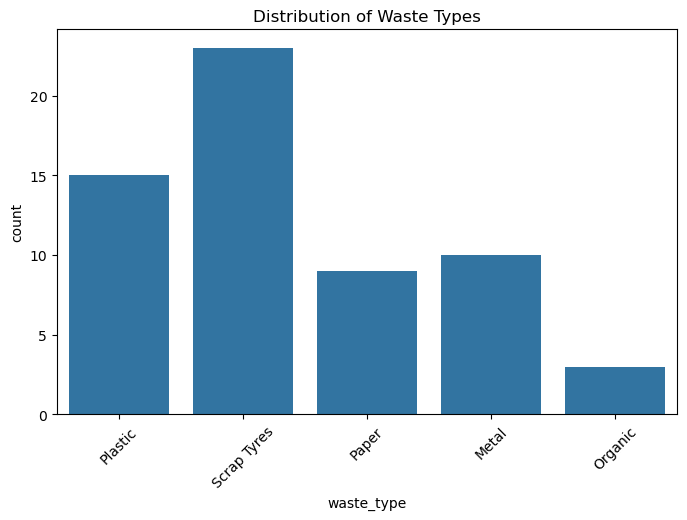

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x="waste_type", data=df)
plt.title("Distribution of Waste Types")
plt.xticks(rotation=45)
plt.show()


### Interpretation

Plastic and scrap tyres appear frequently, indicating they are among the most common recyclable materials in the dataset. This suggests they play a major role in recycling activities.

### Revenue by Waste Type

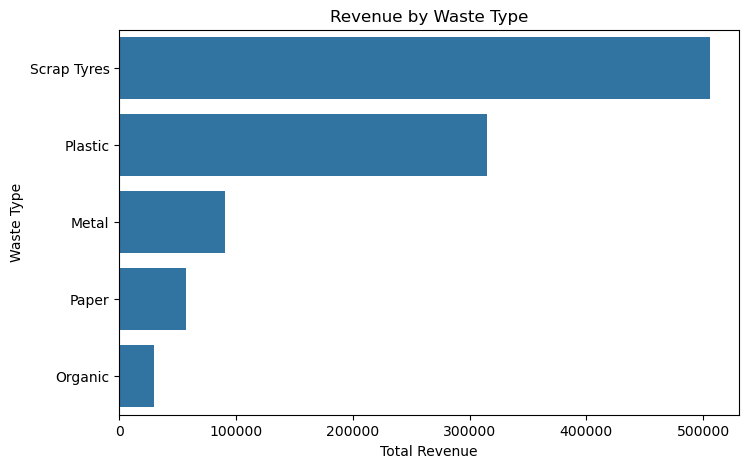

In [12]:
revenue_by_type = df.groupby("waste_type")["total_revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=revenue_by_type.values, y=revenue_by_type.index)
plt.title("Revenue by Waste Type")
plt.xlabel("Total Revenue")
plt.ylabel("Waste Type")
plt.show()

### Revenue Analysis

Scrap tyres and Plastic generate the highest revenue among all waste types.

This indicates that these materials have higher market value and contribute significantly to the profitability of recycling operations.

### Revenue by Area (Lagos Focus)

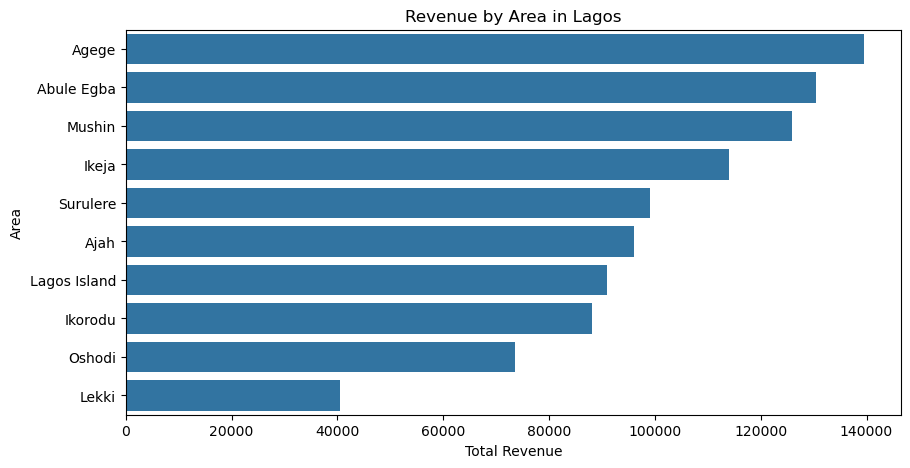

In [13]:
area_revenue = df.groupby("area")["total_revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=area_revenue.values, y=area_revenue.index)
plt.title("Revenue by Area in Lagos")
plt.xlabel("Total Revenue")
plt.ylabel("Area")
plt.show()

### Area-Based Analysis

This analysis reveals differences in recycling revenue across various areas in Lagos. Some areas like Agege and Abule Egba generate significantly higher revenue, indicating higher waste collection or more valuable materials.

This insight can help optimize collection strategies by focusing on high-performing locations.

### Trend Over Time

In [16]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

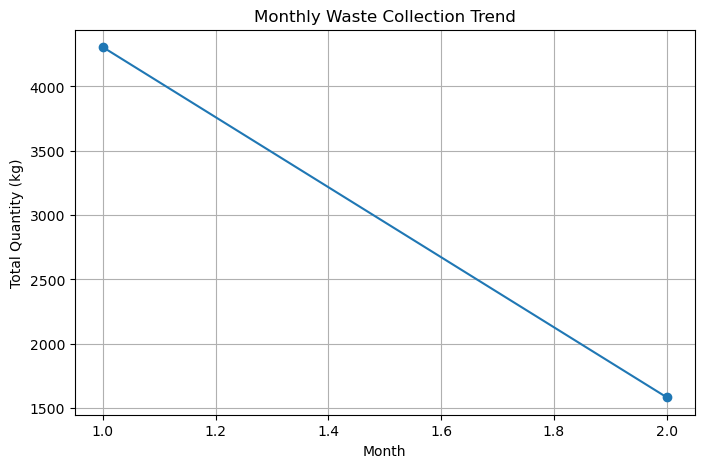

In [17]:
monthly_trend = df.groupby(df["date"].dt.month)["quantity_kg"].sum()

plt.figure(figsize=(8,5))
monthly_trend.plot(marker='o')
plt.title("Monthly Waste Collection Trend")
plt.xlabel("Month")
plt.ylabel("Total Quantity (kg)")
plt.grid(True)
plt.show()

### interpretation

The variation in waste collection over time suggests possible seasonal patterns or operational changes.

Understanding these trends can help improve planning and resource allocation in recycling operations.